# glow_waveforms.glow_bilby: lensed BBH waveforms with glow2


* source models: `glow_waveforms.glow_bilby.source` (`LENSED_WAVEFORMS[model]`, default lens parameters in `DEFAULT_LENS_PARAMS`)
* bilby PE: `glow_waveforms.glow_bilby.bilby_pe` (`priors.get_priors(model)`, `injections`, `run_bilby.py`)
* bilby_pipe PE: `glow_waveforms.glow_bilby.bilby_pipe_pe` (`prior_files/`, `make_ini.py`, example ini)

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import bilby
from bilby.gw.source import lal_binary_black_hole

from glow_waveforms.glow_bilby import source, amplification
from glow_waveforms.glow_bilby.bilby_pe import priors
from glow_waveforms.glow_bilby.source import LENSED_WAVEFORMS, DEFAULT_LENS_PARAMS, BBH_KEYS
from glow_waveforms.glow_bilby.bilby_pe.injections import injection_parameters, get_injection
from glow_waveforms.glow_bilby.bilby_pipe_pe.make_ini import PRIOR_DIR, HERE as PIPE_DIR

bilby.core.utils.logger.setLevel("WARNING")

## Default parameters

In [2]:
injection_parameters  # the BBH injection used by all examples (run_bilby.py, bilby_pipe)

{'mass_1': 35.0,
 'mass_2': 30.0,
 'a_1': 0.42,
 'a_2': 0.1,
 'tilt_1': 1.3,
 'tilt_2': 1.3,
 'phi_12': 1.7,
 'phi_jl': 0.3,
 'luminosity_distance': 1560.0,
 'theta_jn': 0.4,
 'phase': 1.3,
 'ra': 1.375,
 'dec': 1.12108,
 'psi': 2.659,
 'geocent_time': 1126259642.413}

In [3]:
DEFAULT_LENS_PARAMS  # default lens parameters (= keyword defaults of the source functions)

{'UL': {},
 'PL': {'MLz': 1000.0, 'y': 0.2},
 'SIS': {'MLz': 1000.0, 'psi0': 1.0, 'y': 0.2},
 'gSIS': {'MLz': 1000.0, 'psi0': 1.0, 'y': 0.2, 'k': 1.0},
 'NFW': {'MLz': 1000.0, 'psi0': 2.0, 'y': 0.2, 'xs': 1.0},
 'PLshear': {'MLz': 1000.0,
  'psi0': 1.0,
  'y': 1.2,
  'theta': 0.2,
  'g1': 0.5,
  'g2': 0.0,
  'kp': 0.0},
 'PLshear_kpeqg1': {'MLz': 1000.0,
  'psi0': 1.0,
  'y': 1.2,
  'theta': 0.2,
  'g1': 0.4,
  'g2': 0.0},
 'gSISshear': {'MLz': 1000.0,
  'psi0': 1.0,
  'y': 1.2,
  'theta': 0.2,
  'k': 1.0,
  'g1': 0.2,
  'g2': 0.0,
  'kp': 0.0}}

Only the BBH parameters go to the source functions (`ra`, `dec`, `psi`, `geocent_time` are
projection parameters; passing them to `lal_binary_black_hole` triggers bilby's "unused waveform kwargs" warning).

/home/sgoyal/miniconda3/envs/glow2_env/lib/python3.11/site-packages/lalsimulation/_lalsimulation_swig.py:8: UserWarning: Wswiglal-redir-stdio:

SWIGLAL standard output/error redirection is enabled in IPython.
This may lead to performance penalties. To disable locally, use:

with lal.no_swig_redirect_standard_output_error():
    ...

To disable globally, use:

lal.swig_redirect_standard_output_error(False)

Note however that this will likely lead to error messages from
LAL functions being either misdirected or lost when called from
Jupyter notebooks.

To suppress this warning, use:

import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")
import lal

  import lal


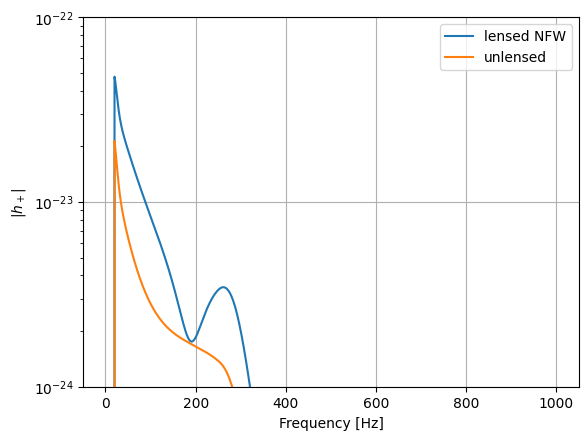

In [4]:
bbh = {k: injection_parameters[k] for k in BBH_KEYS}
frequency_array = np.linspace(0, 1000, 5000)

lens_pols = LENSED_WAVEFORMS['NFW'](frequency_array, **bbh, **DEFAULT_LENS_PARAMS['NFW'])
ul_pols = lal_binary_black_hole(frequency_array, **bbh)

plt.plot(frequency_array, np.abs(lens_pols['plus']), label='lensed NFW')
plt.plot(frequency_array, np.abs(ul_pols['plus']), label='unlensed')
plt.yscale('log')
plt.legend()
plt.ylim(1e-24, 1e-22)
plt.ylabel('$|h_+|$')
plt.grid()
plt.xlabel('Frequency [Hz]')
plt.show()

## Amplification factor directly (low-level API)

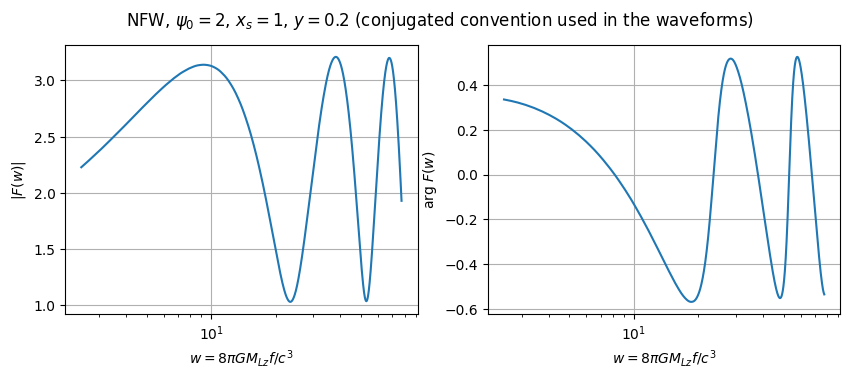

In [5]:
from glow2 import lenses

y, MLz = 0.2, 1000
Psi = lenses.Psi_NFW({'xs': 1, 'psi0': 2})
ids = amplification.restrict_lens_freqs(ul_pols, frequency_array)
w = amplification.GMsun8pi * MLz * frequency_array[ids]
Fws = amplification.get_Fw_sym(Psi, y, w)

fig, ax = plt.subplots(1, 2, figsize=(10, 3.5))
ax[0].semilogx(w, np.abs(Fws)); ax[0].set_ylabel('$|F(w)|$')
ax[1].semilogx(w, np.angle(Fws)); ax[1].set_ylabel('arg $F(w)$')
for a in ax: a.set_xlabel('$w = 8\\pi G M_{Lz} f / c^3$'); a.grid()
fig.suptitle('NFW, $\\psi_0=2$, $x_s=1$, $y=0.2$ (conjugated convention used in the waveforms)')
plt.show()

## Custom parameters: all lens models against the O4 ASD

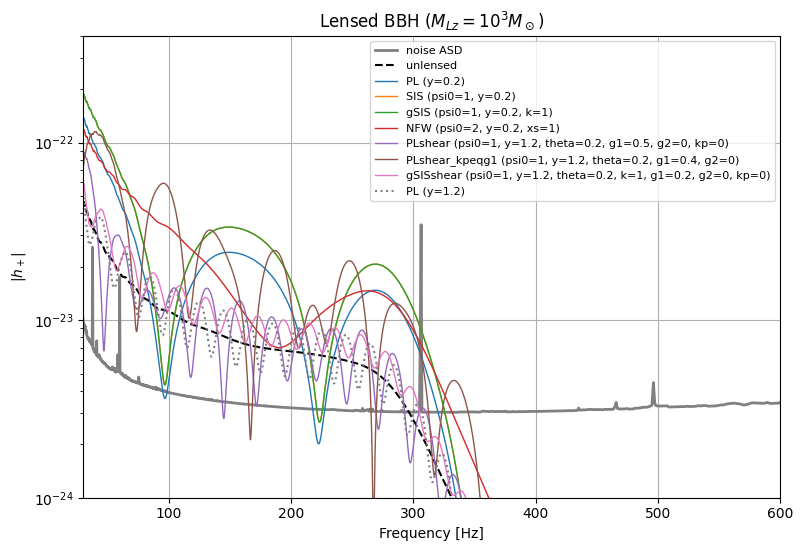

In [6]:
frequency_array = np.linspace(0, 800, 10000)
bbh_near = dict(bbh, luminosity_distance=410)

asd_file = bilby.__path__[0] + '/gw/detector/noise_curves/aLIGO_O4_high_asd.txt'
fre_psd, asd = np.loadtxt(asd_file).T

waveform_arguments = dict(
    waveform_approximant="IMRPhenomXPHM",
    reference_frequency=20.0,
    minimum_frequency=20.0,
)

plt.figure(figsize=(9, 6))
plt.plot(fre_psd, asd, c='gray', lw=2, label='noise ASD')
ul = lal_binary_black_hole(frequency_array, **bbh_near, **waveform_arguments)['plus']
plt.plot(frequency_array, np.abs(ul), 'k--', label='unlensed')

for model, func in LENSED_WAVEFORMS.items():
    if model == 'UL':
        continue
    pols = func(frequency_array, **bbh_near, **DEFAULT_LENS_PARAMS[model], **waveform_arguments)
    lp = ', '.join('{}={:g}'.format(k, v) for k, v in DEFAULT_LENS_PARAMS[model].items() if k != 'MLz')
    plt.plot(frequency_array, np.abs(pols['plus']), label='{} ({})'.format(model, lp), lw=1)

# weak lensing example: PL with y=1.2
pols = LENSED_WAVEFORMS['PL'](frequency_array, **bbh_near, MLz=1e3, y=1.2, **waveform_arguments)
plt.plot(frequency_array, np.abs(pols['plus']), ':', label='PL (y=1.2)')

plt.xlim(30, 600)
plt.ylim(1e-24, 4e-22)
plt.yscale('log')
plt.legend(fontsize=8)
plt.xlabel('Frequency [Hz]')
plt.ylabel('$|h_+|$')
plt.grid()
plt.title('Lensed BBH ($M_{Lz}=10^3 M_\\odot$)')
plt.show()

## bilby: waveform generator, priors, likelihood
Full PE: `python -m glow_waveforms.glow_bilby.bilby_pe.run_bilby <inj_model> <rec_model> <outdir> --npool N`. Here we only
evaluate the likelihood at the injection to show the pieces fit together.

In [7]:
model = 'PLshear_kpeqg1'
inj = get_injection(model)

wfg = bilby.gw.WaveformGenerator(
    duration=4, sampling_frequency=2048,
    frequency_domain_source_model=LENSED_WAVEFORMS[model],
    parameter_conversion=bilby.gw.conversion.convert_to_lal_binary_black_hole_parameters,
    waveform_arguments=waveform_arguments)

ifos = bilby.gw.detector.InterferometerList(['H1', 'L1', 'V1'])
ifos.set_strain_data_from_zero_noise(sampling_frequency=2048, duration=4,
                                     start_time=inj['geocent_time'] - 2)
ifos.inject_signal(waveform_generator=wfg, parameters=inj)

prior = priors.get_priors(model, trigger_time=inj['geocent_time'])
likelihood = bilby.gw.GravitationalWaveTransient(ifos, wfg, priors=prior)
likelihood.parameters.update(inj)
print('log L ratio at injection:', likelihood.log_likelihood_ratio())
likelihood.parameters.update(y=0.5)
print('log L ratio at y=0.5    :', likelihood.log_likelihood_ratio())
prior

log L ratio at injection: 3864.8528925243904
log L ratio at y=0.5    : -1285.1216056852336


{'mass_1': Constraint(minimum=1.001398, maximum=1000, name='mass_1', latex_label='$m_1$', unit=None),
 'mass_2': Constraint(minimum=1.001398, maximum=1000, name='mass_2', latex_label='$m_2$', unit=None),
 'mass_ratio': Uniform(minimum=0.125, maximum=1.0, name='mass_ratio', latex_label='$q$', unit=None, boundary=None),
 'chirp_mass': Uniform(minimum=22.0, maximum=80.0, name='chirp_mass', latex_label='$\\mathcal{M}$', unit='$M_{\\odot}$', boundary=None),
 'luminosity_distance': bilby.gw.prior.UniformComovingVolume(minimum=100.0, maximum=5000.0, cosmology='Planck15', name='luminosity_distance', latex_label='$d_L$', unit='Mpc', boundary=None),
 'dec': Cosine(minimum=-1.5707963267948966, maximum=1.5707963267948966, name='dec', latex_label='$\\mathrm{DEC}$', unit=None, boundary=None),
 'ra': Uniform(minimum=0.0, maximum=6.283185307179586, name='ra', latex_label='$\\mathrm{RA}$', unit=None, boundary='periodic'),
 'theta_jn': Sine(minimum=0.0, maximum=3.141592653589793, name='theta_jn', latex_

## bilby_pipe
The same run with bilby_pipe (see `glow_waveforms/glow_bilby/bilby_pipe_pe/`):
```
python -m glow_waveforms.glow_bilby.bilby_pipe_pe.make_ini PLshear_kpeqg1 PLshear_kpeqg1 --snr 30
bilby_pipe PLshear_kpeqg1_inj_PLshear_kpeqg1_rec.ini --submit
```
Relevant ini entries:

In [8]:
import os
print(open(os.path.join(PRIOR_DIR, 'PLshear_kpeqg1.prior')).read())
print(''.join(l for l in open(os.path.join(PIPE_DIR, 'PLshear_kpeqg1_inj_PLshear_kpeqg1_rec.ini'))
              if l.split('=')[0].strip() in ('prior-file', 'default-prior', 'frequency-domain-source-model',
                                             'injection-frequency-domain-source-model', 'conversion-function')))

# glow_waveforms.glow_bilby default priors: PLshear_kpeqg1 (generated by write_prior_files)
mass_1 = Constraint(minimum=1.001398, maximum=1000, name='mass_1', latex_label='$m_1$', unit=None)
mass_2 = Constraint(minimum=1.001398, maximum=1000, name='mass_2', latex_label='$m_2$', unit=None)
mass_ratio = Uniform(minimum=0.125, maximum=1.0, name='mass_ratio', latex_label='$q$', unit=None, boundary=None)
chirp_mass = Uniform(minimum=22.0, maximum=80.0, name='chirp_mass', latex_label='$\\mathcal{M}$', unit='$M_{\\odot}$', boundary=None)
luminosity_distance = bilby.gw.prior.UniformComovingVolume(minimum=100.0, maximum=5000.0, cosmology='Planck15', name='luminosity_distance', latex_label='$d_L$', unit='Mpc', boundary=None)
dec = Cosine(minimum=-1.5707963267948966, maximum=1.5707963267948966, name='dec', latex_label='$\\mathrm{DEC}$', unit=None, boundary=None)
ra = Uniform(minimum=0.0, maximum=6.283185307179586, name='ra', latex_label='$\\mathrm{RA}$', unit=None, boundary='periodic')
theta_jn =